In [5]:
# ===========================================================
# Predição "só celular" (stack-only: lin + hgb -> meta), sem isotônico e sem tail
# Usa as entradas já definidas na célula anterior:
# - sexo_sujeito, idade_sujeito, Sujeito, df_sp, dt, fs, file_output, corte
# ===========================================================

import os, warnings, joblib
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import skew, kurtosis
import plotly.graph_objects as go

In [6]:
# ===========================================================
# Entradas do sujeito (ajuste aqui)
# ===========================================================
sexo_sujeito  = "M"   # 'M' ou 'F'
idade_sujeito = 64    # anos
Sujeito = '01_atx'

file_sp = f"input_sup/S{Sujeito}.csv"
df_sp = pd.read_csv(file_sp)

dt = 1/60          # intervalo de amostragem (s)
fs = 1/dt          # frequência de amostragem (Hz)

# Saída
file_output = 'Outputs/'  # pasta de saída
corte_s = 0      # segundos a cortar nas bordas

In [7]:
# -*- coding: utf-8 -*-
import os, numpy as np, pandas as pd, joblib, warnings
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import CubicSpline
from scipy.stats import skew, kurtosis
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

# ==================== CONFIG ====================
model_path = "calibrador_global_SP2VC_features_stack.joblib"  # ajuste se necessário

# Detector de picos
peak_mode   = "height"   # "height" ou "prom"
peak_height = 70.0      # deg/s (se usar mode="height")
peak_prom   = 0.30       # fração do desvio padrão (se mode="prom")
min_dist_s  = 0.5       # distância mínima entre picos em segundos
use_vector_mag = False   # True => detectar picos no módulo vetorial |ω|
align_axis      = "X"    # se use_vector_mag=False: "X", "Y" ou "Z"

# Janela de features (meia-janela em s)
win_s = 0.12

# ==================== HELPERS ====================
DT = float(dt); FS = float(fs)
assert np.isclose(FS, 1.0/DT), "fs e dt inconsistentes"

def lowpass(x, fs=FS, fc=4.0, order=4):
    b, a = butter(order, fc/(fs/2), "low"); return filtfilt(b, a, x)

def resample_uniform(t, y, dt=DT):
    t = np.asarray(t); y = np.asarray(y)
    if not np.all(np.diff(t) > 0):
        idx = np.unique(t, return_index=True)[1]; t = t[idx]; y = y[idx]
        srt = np.argsort(t); t = t[srt]; y = y[srt]
    if t.size < 3: return np.array([]), np.array([])
    tn = np.arange(t.min(), t.max(), dt)
    if tn.size < 3: return np.array([]), np.array([])
    try:
        yn = CubicSpline(t, y)(tn)
    except Exception:
        return np.array([]), np.array([])
    return tn, yn

def peaks_generic(sig, fs=FS, mode="height", height=115.0, prom=0.3, min_dist_s=0.25):
    if len(sig) < 10 or np.allclose(np.std(sig), 0.0): return np.array([], dtype=int)
    dist = max(1, int(round(min_dist_s * fs)))
    if mode == "prom":
        prominence = max(prom * np.std(sig), 1e-9)
        idx, _ = find_peaks(sig, distance=dist, prominence=prominence)
    else:
        idx, _ = find_peaks(sig, distance=dist, height=float(height))
    return idx

def parabolic_peak(t, y, i):
    i = int(i)
    if i <= 0 or i >= len(y) - 1: return float(t[i]), float(y[i]), int(i)
    y0, y1, y2 = y[i-1], y[i], y[i+1]
    d = (y0 - 2*y1 + y2)
    if d == 0: return float(t[i]), float(y1), int(i)
    delta = 0.5*(y0 - y2)/d
    tpk   = t[i] + delta*(t[i+1]-t[i])
    ypk   = y1 - 0.25*(y0 - y2)*delta
    return float(tpk), float(ypk), int(i)

def sp_feats(seg, fs=FS):
    x = np.asarray(seg).astype(float); L = len(x); dt = 1.0/fs
    keys = ["f_peak_sp","f_p95_sp","f_p98_sp","f_mean_sp","f_std_sp","f_rms_sp",
            "f_skew_sp","f_kurt_sp","f_width80_s","f_slope_top",
            "f_cycle_dur_s","f_cycle_freq_hz","f_area_pos","f_energy","f_zc","f_ratio_peak_med"]
    if L < 5: return {k: np.nan for k in keys}
    peak = float(x.max()); idx = int(np.argmax(x))
    feats = dict(
        f_peak_sp=peak, f_p95_sp=float(np.percentile(x,95)), f_p98_sp=float(np.percentile(x,98)),
        f_mean_sp=float(np.mean(x)), f_std_sp=float(np.std(x)), f_rms_sp=float(np.sqrt(np.mean(x**2)))
    )
    feats["f_skew_sp"] = float(skew(x,bias=False)) if L>3 else 0.0
    feats["f_kurt_sp"] = float(kurtosis(x,fisher=True,bias=False)) if L>3 else 0.0
    feats.update(
        f_cycle_dur_s=float(L*dt),
        f_cycle_freq_hz=float(1.0/(L*dt)) if L>0 else np.nan,
        f_area_pos=float(np.sum(x[x>0])*dt),
        f_energy=float(np.sum(x**2)*dt),
        f_zc=int(np.where(np.diff(np.sign(x))!=0)[0].size),
        f_ratio_peak_med=float(peak/(np.median(x)+1e-9))
    )
    thr = 0.8*peak; above = np.where(x>=thr)[0]
    feats["f_width80_s"] = float((above[-1]-above[0])*dt) if above.size>1 else 0.0
    half = int(round(0.04*fs)); a = max(0, idx-half); b = min(L, idx+half+1)
    t_loc = np.arange(b-a)*dt; y_loc = x[a:b]
    feats["f_slope_top"] = float(np.polyfit(t_loc, y_loc, 1)[0]) if len(t_loc)>1 else 0.0
    return feats

def predict_stack_only(bundle, Xrow):
    if isinstance(bundle, dict) and all(k in bundle for k in ["lin","hgb","meta"]):
        lin, hgb, meta = bundle["lin"], bundle["hgb"], bundle["meta"]
        pred_lin = lin.predict(Xrow).astype(float).ravel()
        pred_hgb = hgb.predict(Xrow).astype(float).ravel()
        Z = np.column_stack([pred_lin, pred_hgb])
        target_mode = bundle.get("target_mode","raw")
        if target_mode == "log": return np.expm1(meta.predict(Z)).astype(float)
        return meta.predict(Z).astype(float)
    if hasattr(bundle, "predict"): return bundle.predict(Xrow).astype(float)
    raise RuntimeError("Calibrador não reconhecido (esperado bundle lin/hgb/meta).")

# ==================== PIPELINE ====================
os.makedirs(file_output, exist_ok=True)

bundle = joblib.load(model_path)
feat_cols = bundle.get("feat_cols", None) if isinstance(bundle, dict) else None
expects_cols = set(feat_cols) if isinstance(feat_cols, list) else None
need_Y = any(c.startswith("fY_") for c in expects_cols) if expects_cols else False
need_Z = any(c.startswith("fZ_") for c in expects_cols) if expects_cols else False
need_XYZ = (need_Y or need_Z) or (expects_cols and (("w_peak_phoneY_deg_s" in expects_cols) or ("w_peak_phoneZ_deg_s" in expects_cols)))

# ---- 1) Ler CSV e uniformizar ----
col_t = "gyroTimestamp_sinceReboot(s)"
col_x = "gyroRotationX(rad/s)"
col_y = "gyroRotationY(rad/s)"
col_z = "gyroRotationZ(rad/s)"
assert col_t in df_sp.columns and col_x in df_sp.columns, "CSV sem colunas obrigatórias."

have_Y = col_y in df_sp.columns
have_Z = col_z in df_sp.columns

tX, x_u = resample_uniform(df_sp[col_t].values, df_sp[col_x].values, DT)
if tX.size < 10: raise SystemExit("Sinal X muito curto.")
Xf = lowpass(np.rad2deg(x_u))

if have_Y:
    tY, y_u = resample_uniform(df_sp[col_t].values, df_sp[col_y].values, DT)
    Yf = lowpass(np.rad2deg(y_u)) if tY.size>=10 else None; have_Y = Yf is not None
else:
    Yf = None

if have_Z:
    tZ, z_u = resample_uniform(df_sp[col_t].values, df_sp[col_z].values, DT)
    Zf = lowpass(np.rad2deg(z_u)) if tZ.size>=10 else None; have_Z = Zf is not None
else:
    Zf = None

# grade base (sem 'corte'; cortaremos por 0..120 s mais abaixo)
t0 = max(tX.min(), (tY.min() if have_Y else tX.min()), (tZ.min() if have_Z else tX.min()))
t1 = min(tX.max(), (tY.max() if have_Y else tX.max()), (tZ.max() if have_Z else tX.max()))
t = np.arange(t0, t1, DT)

# interpolar na grade final
X = np.interp(t, tX, Xf)
Y = np.interp(t, tY, Yf) if have_Y else None
Z = np.interp(t, tZ, Zf) if have_Z else None

# ---- 2) Sinal de detecção + CORTE INICIAL (variável) + picos (na série completa) ----
if use_vector_mag and (Y is not None) and (Z is not None):
    det_sig = np.sqrt(X**2 + Y**2 + Z**2); det_name = "mag"
else:
    axis = align_axis.upper()
    det_sig = {"X": X, "Y": (Y if Y is not None else X), "Z": (Z if Z is not None else X)}[axis]
    det_name = axis

# >>>>> CORTE INICIAL AQUI (usa 'corte' definido na célula 1) <<<<<
try:
    corte_s = float(corte_s)
except NameError:
    corte_s = 0.0

if corte_s > 0:
    t_start = t[0] + corte_s
    mask_corte = (t >= t_start)

    t = t[mask_corte]
    X = X[mask_corte]
    if Y is not None: Y = Y[mask_corte]
    if Z is not None: Z = Z[mask_corte]
    det_sig = det_sig[mask_corte]

    if t.size < 10:
        raise SystemExit(f"Sinal ficou curto demais após corte inicial de {corte_s:.2f}s.")
# >>>>> FIM DO CORTE INICIAL <<<<<

idx_full = peaks_generic(det_sig, FS, peak_mode, peak_height, peak_prom, min_dist_s)
if idx_full.size == 0: raise SystemExit("Nenhum pico detectado.")

# ---- 3) Zero = último cruzamento (−→+) antes do 1º pico ----
first_peak_idx = int(idx_full[0])
pre_win = int(round(2.0 * FS))
a = max(0, first_peak_idx - pre_win)
b = first_peak_idx
local_offset = float(np.mean(det_sig[a:b])) if b > a else float(np.mean(det_sig[:first_peak_idx]))
zc_sig = det_sig - local_offset
rising = np.where((zc_sig[:-1] <= 0) & (zc_sig[1:] > 0))[0]
prev_rising = rising[rising < first_peak_idx]
if prev_rising.size > 0:
    zero_idx = int(prev_rising[-1] + 1)
else:
    zero_idx = int(np.argmin(np.abs(zc_sig[:first_peak_idx]))) if first_peak_idx > 0 else 0

# recortar a série a partir do zero
t   = t[zero_idx:]
X   = X[zero_idx:]
Y   = (Y[zero_idx:] if Y is not None else None)
Z   = (Z[zero_idx:] if Z is not None else None)
det_sig = det_sig[zero_idx:]

# tempos relativos
t_rel = t - t[0]

# limitar a 0..120 s
mask_120 = (t_rel <= 120.0)
t_rel = t_rel[mask_120]
X = X[mask_120]
if Y is not None: Y = Y[mask_120]
if Z is not None: Z = Z[mask_120]
det_sig = det_sig[mask_120]

# ---- 4) (Re)detectar picos na janela 0..120 s ----
idx = peaks_generic(det_sig, FS, peak_mode, peak_height, peak_prom, min_dist_s)
if idx.size == 0: raise SystemExit("Nenhum pico após recorte 0..120 s.")
win = int(round(win_s * FS))

# ---- 5) Loop de picos -> features -> predição ----
rows = []; t_phone_peaks, y_phone_peaks = [], []
t_pred_peaks,  y_pred_peaks  = [], []

bundle = bundle  # já carregado
feat_cols = bundle.get("feat_cols", None) if isinstance(bundle, dict) else None
expects_cols = set(feat_cols) if isinstance(feat_cols, list) else None
need_Y = any(c.startswith("fY_") for c in expects_cols) if expects_cols else False
need_Z = any(c.startswith("fZ_") for c in expects_cols) if expects_cols else False
need_XYZ = (need_Y or need_Z) or (expects_cols and (("w_peak_phoneY_deg_s" in expects_cols) or ("w_peak_phoneZ_deg_s" in expects_cols)))

for k, i_p in enumerate(idx, start=1):
    s = max(i_p - win, 0); e = min(i_p + win + 1, len(t_rel))
    t_win = t_rel[s:e]
    Xw = X[s:e].astype(float)
    Yw = (Y[s:e].astype(float) if Y is not None else None)
    Zw = (Z[s:e].astype(float) if Z is not None else None)
    if len(Xw) < 5: continue

    tpk, ypk, _ = parabolic_peak(t_rel, det_sig, i_p)
    t_phone_peaks.append(float(tpk)); y_phone_peaks.append(float(ypk))

    ipx = int(np.argmax(Xw)); _, ypk_x, _ = parabolic_peak(t_win, Xw, ipx)
    if Yw is not None:
        ipy = int(np.argmax(Yw)); _, ypk_y, _ = parabolic_peak(t_win, Yw, ipy)
    else: ypk_y = np.nan
    if Zw is not None:
        ipz = int(np.argmax(Zw)); _, ypk_z, _ = parabolic_peak(t_win, Zw, ipz)
    else: ypk_z = np.nan

    fX = {f"fX_{k2}": v for k2, v in sp_feats(Xw, FS).items()}
    if need_XYZ:
        fY = {f"fY_{k2}": v for k2, v in sp_feats(Yw if Yw is not None else [0,0,0], FS).items()}
        fZ = {f"fZ_{k2}": v for k2, v in sp_feats(Zw if Zw is not None else [0,0,0], FS).items()}
    else:
        fY, fZ = {}, {}
    feats = {}; feats.update(fX); feats.update(fY); feats.update(fZ)
    feats["w_peak_phoneX_deg_s"] = float(ypk_x)
    if need_XYZ:
        feats["w_peak_phoneY_deg_s"] = float(ypk_y)
        feats["w_peak_phoneZ_deg_s"] = float(ypk_z)

    if feat_cols is not None:
        Xrow = np.array([[feats.get(c, np.nan) for c in feat_cols]], dtype=float)
    else:
        keys = sorted(feats.keys()); Xrow = np.array([[feats[k] for k in keys]], dtype=float)

    y_pred = float(predict_stack_only(bundle, Xrow)[0])
    t_pred_peaks.append(float(tpk)); y_pred_peaks.append(float(y_pred))

    rows.append(dict(
        sujeito=Sujeito, sexo=sexo_sujeito, idade=idade_sujeito,
        peak_idx=int(k), t_peak_phone_s=float(tpk), detect_signal=det_name,
        w_phoneX_peak_deg_s=float(ypk_x),
        w_phoneY_peak_deg_s=float(ypk_y),
        w_phoneZ_peak_deg_s=float(ypk_z),
        w_pred_deg_s=float(y_pred)
    ))

# ---- 6) Exportar CSV ----
if not rows: raise SystemExit("Nenhum ciclo válido para exportar.")
df_pred = pd.DataFrame(rows)
csv_path_out = os.path.join(file_output, f"predict_phone_S{Sujeito}.csv")
df_pred.to_csv(csv_path_out, index=False)
print(f"[OK] {len(df_pred)} picos (stack-only) | janela 0–120 s | detecção: {det_name}")
print(f"     CSV salvo: {csv_path_out}")

# ---- 7) Plot: eixo 0–120 s e linhas de referência ----
fig = go.Figure()
if det_name == "mag":
    mag = np.sqrt((X**2)+((Y if Y is not None else 0)**2)+((Z if Z is not None else 0)**2))
    fig.add_trace(go.Scatter(x=t_rel, y=mag, mode="lines",
                             name="Phone | |ω| (mag)", line=dict(width=2)))
else:
    sig_map = {"X": X, "Y": (Y if Y is not None else X), "Z": (Z if Z is not None else X)}
    fig.add_trace(go.Scatter(x=t_rel, y=sig_map[det_name], mode="lines",
                             name=f"Phone | gyro {det_name}", line=dict(width=2)))

fig.add_trace(go.Scatter(x=np.array(t_phone_peaks), y=y_phone_peaks, mode="markers",
                         name="Picos phone (brutos)", marker=dict(size=8, symbol="circle")))
fig.add_trace(go.Scatter(x=np.array(t_pred_peaks), y=y_pred_peaks, mode="markers",
                         name="Picos calibrados (stack)", marker=dict(size=10, symbol="circle-open")))

fig.add_vline(x=0.0,  line_width=1, line_dash="dot")
fig.add_vline(x=120., line_width=1, line_dash="dot")

fig.update_layout(
    title=f"Calibrated peaks (stack-only)",
    xaxis_title="Time (s)",
    yaxis_title="Angular Velocity (°/s)",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    xaxis=dict(range=[0, 120])
)

fig.show()
fig.write_html(os.path.join(file_output, f"predict_phone_S{Sujeito}_series.html"), include_plotlyjs="cdn")

# preview
df_pred.head()


[OK] 53 picos (stack-only) | janela 0–120 s | detecção: X
     CSV salvo: Outputs/predict_phone_S01_atx.csv


,sujeito,sexo,idade,peak_idx,t_peak_phone_s,detect_signal,w_phoneX_peak_deg_s,w_phoneY_peak_deg_s,w_phoneZ_peak_deg_s,w_pred_deg_s
0,01_atx,M,64,1,0.217547,X,175.971797,47.105935,67.016844,224.754277
1,01_atx,M,64,2,2.942186,X,201.350200,74.565943,64.875373,220.842045
2,01_atx,M,64,3,5.219088,X,197.792324,75.587536,68.381716,220.012186
3,01_atx,M,64,4,7.503711,X,216.692870,64.589842,66.214102,224.494241
4,01_atx,M,64,5,9.744918,X,213.929100,74.693690,61.812098,222.321457


[OK] Summary exported to Excel: Outputs/predict_phone_S01_atx.xlsx


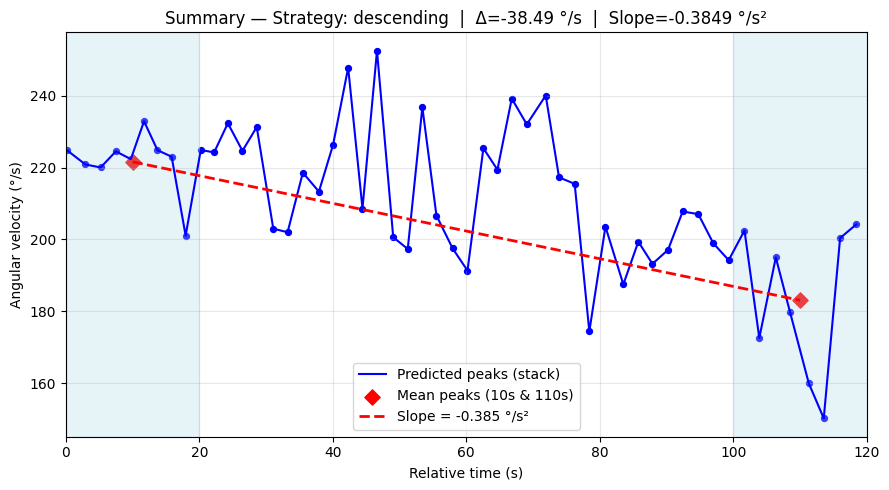

In [8]:
# =========================
# SUMMARY for Excel + Plot (English version)
# =========================

import math, matplotlib.pyplot as plt

t_pred = np.array(t_pred_peaks, dtype=float)
v_pred = np.array(y_pred_peaks, dtype=float)

if v_pred.size == 0:
    raise SystemExit("No predicted peaks to summarize.")

# --- parameters ---
threshold = 11.0           # strategy threshold
t_start, t_end = 0.0, 120.0
duration = float(t_end - t_start)

# --- 20 s windows ---
ini_t0, ini_t1 = 0.0, 20.0
end_t0, end_t1 = 100.0, 120.0

mask_ini = (t_pred >= ini_t0) & (t_pred <= ini_t1)
mask_end = (t_pred >= end_t0) & (t_pred <= end_t1)

Vm_ini = float(np.mean(v_pred[mask_ini])) if np.any(mask_ini) else np.nan
Vm_end = float(np.mean(v_pred[mask_end])) if np.any(mask_end) else np.nan

# --- strategy (based on 11 deg/s difference) ---
delta_vm = Vm_end - Vm_ini if (not math.isnan(Vm_end) and not math.isnan(Vm_ini)) else np.nan
if np.isnan(delta_vm):
    strategy = "undefined"
elif delta_vm > threshold:
    strategy = "ascending"
elif delta_vm < -threshold:
    strategy = "descending"
else:
    strategy = "constant"

# --- slope coefficient (line between midpoints of the 20 s windows) ---
tA, tB = 10.0, 110.0
slope = np.nan
if (not math.isnan(Vm_ini)) and (not math.isnan(Vm_end)):
    slope = (Vm_end - Vm_ini) / (tB - tA)  # deg/s²

# --- general statistics ---
N = int(v_pred.size)
cadence = N / 2.0
Vm_total = float(np.mean(v_pred))
std_vel  = float(np.std(v_pred, ddof=0))
cv_vel   = float(std_vel / (Vm_total + 1e-9))
vel_max  = float(np.max(v_pred))
vel_min  = float(np.min(v_pred))

if t_pred.size >= 2:
    isi = np.diff(t_pred)
    time_mean = float(np.mean(isi))
    std_time  = float(np.std(isi, ddof=0))
    cv_time   = float(std_time / (time_mean + 1e-9))
    time_max  = float(np.max(isi))
    time_min  = float(np.min(isi))
else:
    time_mean = std_time = cv_time = time_max = time_min = np.nan

# --- DataFrame for Excel ---
cols = ["N#", "Strategy", "Cadence (cycles/min)",
        "Vel ini", "Vel end", "Slope (deg/s²)",
        "Vel mean", "Vel SD", "CV Vel",
        "Vel max", "Vel min",
        "Time mean", "Time SD", "CV Time", "Time max", "Time min"]

df_xlsx = pd.DataFrame([{
    "N#": N,
    "Strategy": strategy,
    "Cadence (cycles/min)": cadence,
    "Vel ini": Vm_ini,
    "Vel end": Vm_end,
    "Slope (deg/s²)": slope,
    "Vel mean": Vm_total,
    "Vel SD": std_vel,           # standard deviation (instead of variance)
    "CV Vel": cv_vel,
    "Vel max": vel_max,
    "Vel min": vel_min,
    "Time mean": time_mean,
    "Time SD": std_time,         # standard deviation (instead of variance)
    "CV Time": cv_time,
    "Time max": time_max,
    "Time min": time_min
}])[cols]

xlsx_path_out = os.path.join(file_output, f"predict_phone_S{Sujeito}.xlsx")
with pd.ExcelWriter(xlsx_path_out, engine="xlsxwriter") as writer:
    df_xlsx.to_excel(writer, index=False, sheet_name="Summary")

print(f"[OK] Summary exported to Excel: {xlsx_path_out}")

# =========================
# SUMMARY PLOT
# =========================
plt.figure(figsize=(9,5))
plt.plot(t_pred, v_pred, 'b-', label='Predicted peaks (stack)')
plt.scatter(t_pred, v_pred, color='blue', s=18)

# midpoints of the 20 s windows
plt.scatter([tA, tB], [Vm_ini, Vm_end], color='red', s=60, marker='D', label='Mean peaks (10s & 110s)')

# slope line
plt.plot([tA, tB], [Vm_ini, Vm_end], 'r--', lw=2, label=f"Slope = {slope:.3f} °/s²")

# shaded windows (0–20s and 100–120s)
plt.axvspan(ini_t0, ini_t1, color='lightblue', alpha=0.3)
plt.axvspan(end_t0, end_t1, color='lightblue', alpha=0.3)

plt.xlim(0, 120)
plt.xlabel("Relative time (s)")
plt.ylabel("Angular velocity (°/s)")
plt.title(f"Summary — Strategy: {strategy}  |  Δ={delta_vm:+.2f} °/s  |  Slope={slope:.4f} °/s²")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
